# Global population and Net migration ![](https://blog.dhsprogram.com/wp-content/uploads/Ruchaneek_Adobe-Stock-scaled.jpeg)


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated", category=FutureWarning)


In [64]:
df= pd.read_csv('/kaggle/input/global-population-and-migration-dataset/world_pop_mig_186_countries.csv')
df.head(5)

,country,year,population,netMigration,population_in_millions
0,Afghanistan,2023,42239854.0,-65846.0,42
1,Afghanistan,2022,41128771.0,-65846.0,41
2,Afghanistan,2021,40099462.0,-183672.0,40
3,Afghanistan,2020,38972230.0,166821.0,38
4,Afghanistan,2019,37769499.0,-8082.0,37


In [65]:
df.dtypes

country                    object
year                        int64
population                float64
netMigration              float64
population_in_millions      int64
dtype: object

In [66]:
df.isna().sum()

country                   0
year                      0
population                0
netMigration              0
population_in_millions    0
dtype: int64

In [67]:
df.describe()

,year,population,netMigration,population_in_millions
count,11904.000000,1.190400e+04,1.190400e+04,11904.000000
mean,1991.500000,2.703863e+07,7.482505e+02,26.618868
std,18.473729,1.128305e+08,1.621035e+05,112.812944
min,1960.000000,2.646000e+03,-6.673580e+06,0.000000
25%,1975.750000,5.973292e+05,-1.325250e+04,0.000000
50%,1991.500000,4.342186e+06,-4.840000e+02,4.000000
75%,2007.250000,1.333759e+07,5.505500e+03,13.000000
max,2023.000000,1.428628e+09,3.366387e+06,1428.000000


# <span style="color:Brown">Lets look at the country with the highest net migration in 2023</span>


In [68]:
top=df[df['year']==2023].groupby('country')['netMigration'].agg(['sum']).sort_values(by='sum',ascending=False).head(10)
top=top.reset_index()
top.head(10)


,country,sum
0,Ukraine,1784718.0
1,United States,999700.0
2,Syrian Arab Republic,757103.0
3,Canada,249746.0
4,United Kingdom,165790.0
5,Germany,155751.0
6,Australia,139991.0
7,Japan,99994.0
8,France,67761.0
9,Italy,58496.0


# Highest number of net migration in the year 2023

The net migration data for 2023 reveals a significant influx of people into the listed countries, with Ukraine experiencing the largest positive net migration of 1,784,718, likely influenced by ongoing conflicts and displacement. The United States follows closely with 999,700, reflecting its status as a major destination for migrants seeking better economic opportunities, safety, and political stability. Other countries with substantial positive net migration include the Syrian Arab Republic (757,103), likely due to people seeking refuge from ongoing conflict, and Canada (249,746), which is known for its welcoming immigration policies. The United Kingdom (165,790), Germany (155,751), and Australia (139,991) also show significant positive net migration, driven by factors such as economic opportunities, better quality of life, and political stability. Japan (99,994) and France (67,761) report moderate net migration, with Italy (58,496) seeing the lowest in this group. This trend suggests that these countries remain attractive to migrants, whether for economic, social, or political reasons, contributing to demographic and labor force changes in these regions.


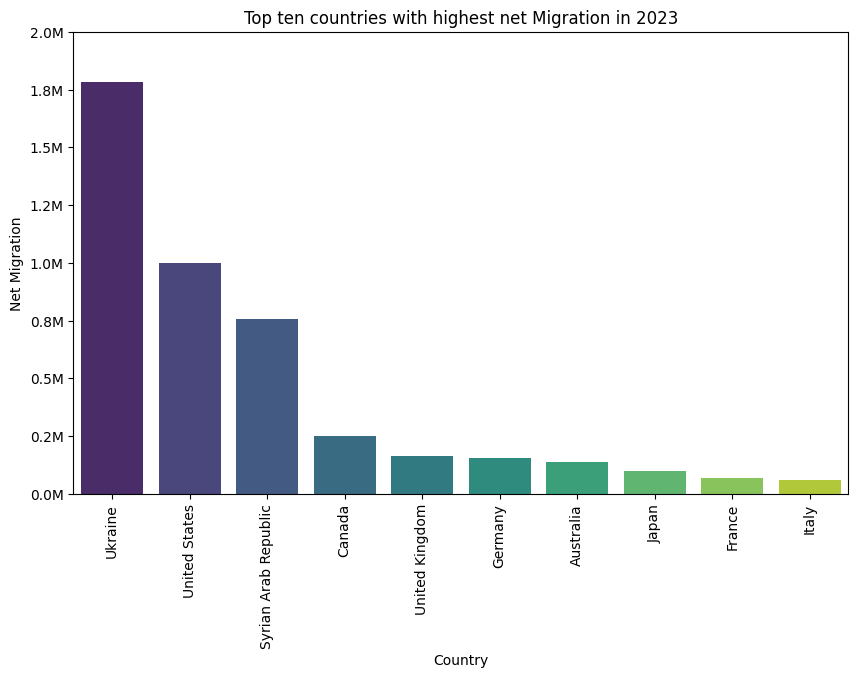

In [69]:
import matplotlib.ticker as mtick


plt.figure(figsize=(10,6))
t=sns.barplot(data=top,x='country',y='sum',palette='viridis')
plt.xticks(rotation=90)
t.set(xlabel='Country',ylabel='Net Migration',title='Top ten countries with highest net Migration in 2023')
current_ticks = plt.gca().get_yticks()
plt.yticks(current_ticks, [f'{x/1e6:.1f}M' for x in current_ticks])
plt.show()

# Highest Net out migration in 2023


In [70]:
low=df[df['year']==2023].groupby('country')['netMigration'].agg(['sum']).sort_values(by='sum',ascending=True).head(10)
low=low.reset_index()
low.head(10)

,country,sum
0,Poland,-910475.0
1,India,-486136.0
2,China,-310220.0
3,Bangladesh,-309977.0
4,Romania,-254616.0
5,Lebanon,-177331.0
6,Colombia,-175051.0
7,Pakistan,-165988.0
8,Jordan,-157392.0
9,Hungary,-156677.0


**The net migration data for the year 2023 shows that the countries listed have experienced significant negative net migration. This indicates that more people have left these countries than entered them. For example, Poland stands out with the largest negative net migration of -910,475, followed by India with -486,136 and China with -310,220. Other countries like Bangladesh (-309,977), Romania (-254,616), and Lebanon (-177,331) also show substantial emigration. This suggests a trend where people are likely leaving these countries for better economic opportunities, safety, or social conditions elsewhere. The large outflows of people from countries like Poland and India may reflect high levels of labor migration or economic factors prompting individuals to seek opportunities abroad. This pattern of negative net migration could have significant socio-economic implications for these countries, particularly in terms of labor force shortages, demographic shifts, and potential long-term impacts on their economies and societies.**

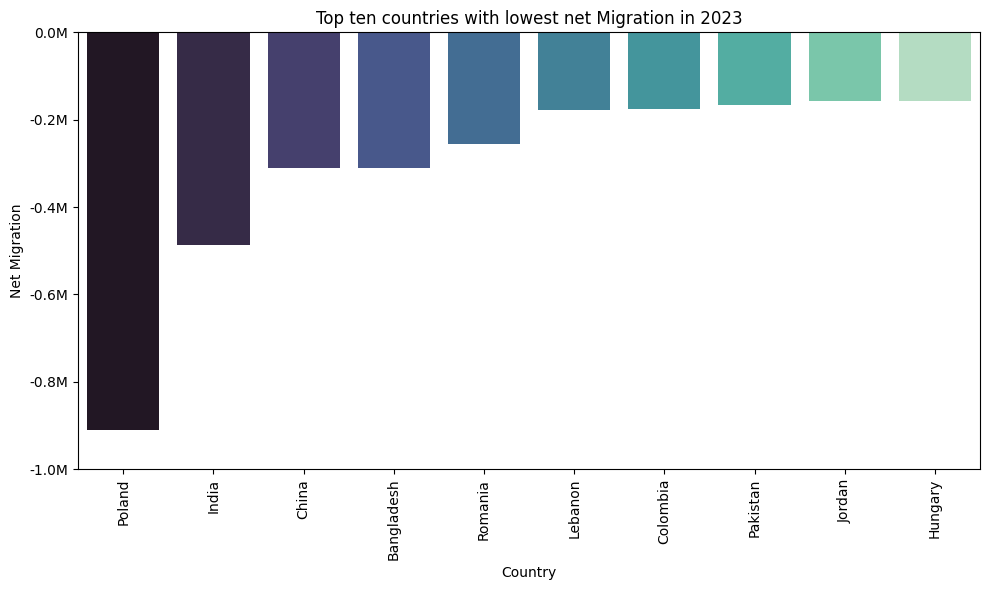

In [71]:
import matplotlib.ticker as mtick


plt.figure(figsize=(10,6))
t=sns.barplot(data=low,x='country',y='sum',palette='mako')
plt.xticks(rotation=90)
t.set(xlabel='Country',ylabel='Net Migration',title='Top ten countries with lowest net Migration in 2023')
current_ticks = plt.gca().get_yticks()
plt.yticks(current_ticks, [f'{x/1e6:.1f}M' for x in current_ticks])
plt.tight_layout() 
plt.show()

In [72]:
df[df['netMigration']==df['netMigration'].max()]

,country,year,population,netMigration,population_in_millions
8705,Poland,2022,36821749.0,3366387.0,36


In [73]:
df['population'].corr(df['netMigration'])

-0.08919536294669217

# We will be looking mainly at the data of Nepal

In [74]:
Nepal=df[df['country']=='Nepal']

In [75]:
nepal=df[df['country']=='Nepal'].groupby('year')['netMigration'].agg(['sum'])
nepal.sort_values(by='sum',ascending=False).head(5)

,sum
year,
2020,306664.0
2021,296541.0
1992,84106.0
1991,17056.0
1980,5084.0


# Impact of Covid to the Net migration trends

*We can clearly see the impact of covid in the net migration of the country.In Nepa we can see the trend of people going abroad for educational and work purposes. We can see that period of covid the country had positive net migration means people staying abroad came to Nepal during those periods because of all the restrications and condition of the situation.*

Text(0, 0.5, 'Net Migration')

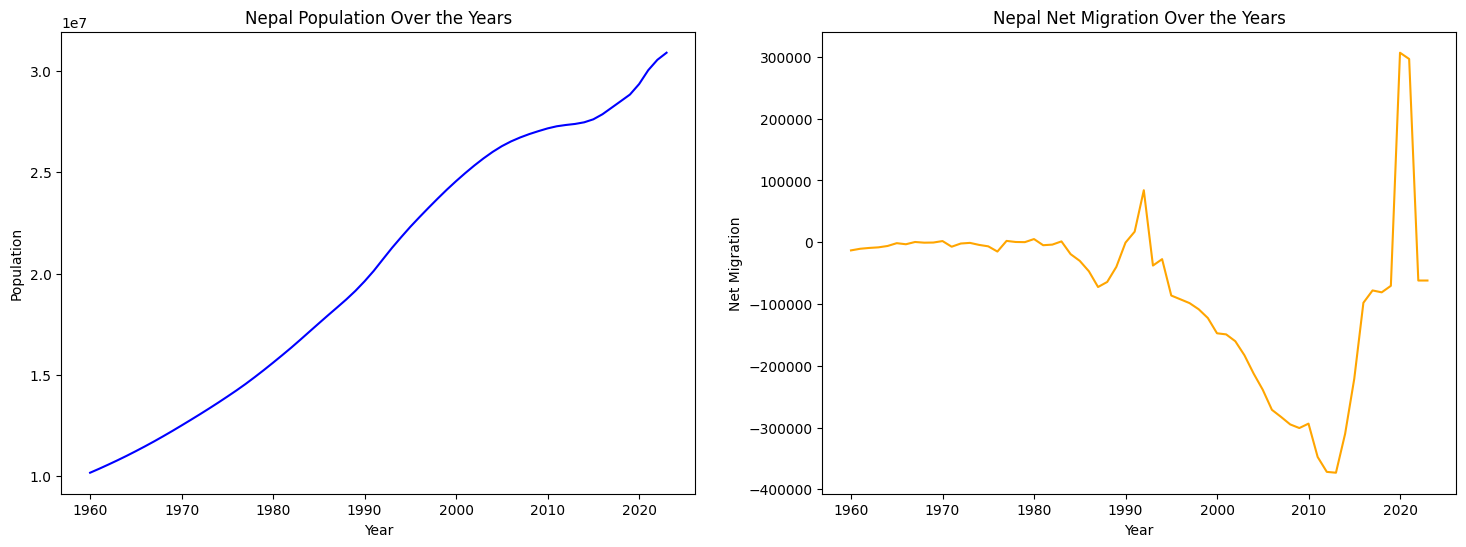

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# population over the year
sns.set_style()
sns.lineplot(data=Nepal, x='year', y='population', ax=axes[0], color='blue')
axes[0].set_title('Nepal Population Over the Years')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Population')

# Net migration over the years
sns.lineplot(data=Nepal, x='year', y='netMigration', ax=axes[1], color='orange')
axes[1].set_title('Nepal Net Migration Over the Years')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Net Migration')


In [77]:
nepala=df[df['country']=='Nepal']
nepala['population'].corr(nepala['netMigration'])

-0.46252698993238334

**A correlation of -0.46 between population and net migration in the context of Nepal suggests a moderate negative relationship. Here's what this means in the specific context:**
<span style="color:black">Interpretation of -0.46 Correlation in Nepal:
Moderate Negative Correlation: As net migration increases (more people leaving the country or fewer people coming in), the population tends to decrease, but this relationship is not strong, meaning other factors also influence population size. Conversely, when net migration decreases (fewer people leaving or more people entering), population tends to increase.background-color:magenta / font-family:newtimeroman</span>





